In [173]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

In [174]:
df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/refs/heads/master/titanic.csv')[['Survived','Age','Fare']]

In [175]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [176]:
df['Age'].fillna(df['Age'].mean(),inplace=True)

In [177]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(df.iloc[:,1:], df.iloc[:,0],random_state=42, test_size=0.2)

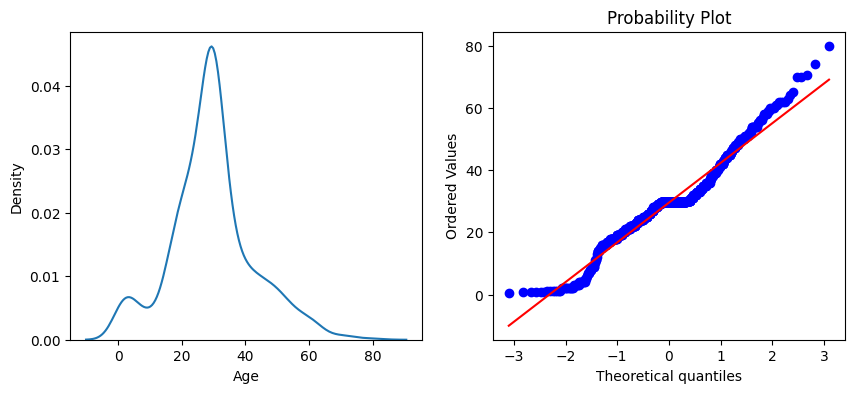

In [178]:
plt.figure(figsize=(10,4))
plt.subplot(121)
sns.kdeplot(x_train, x = "Age")
plt.subplot(122)
stats.probplot(x_train['Age'], dist="norm", plot=plt)
plt.show()

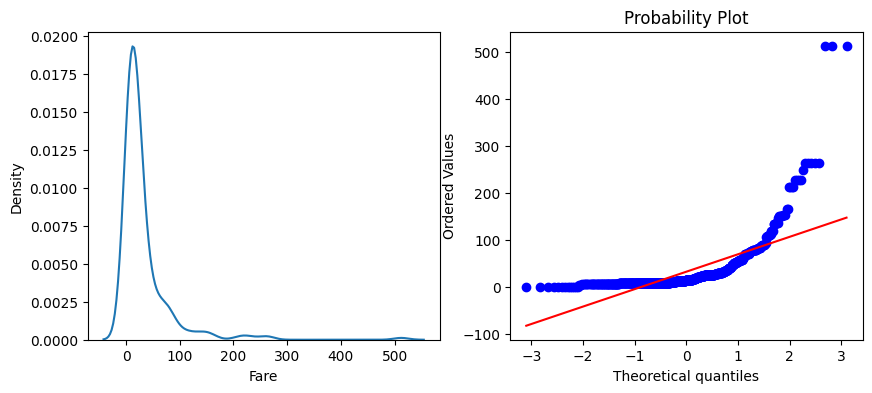

In [179]:
plt.figure(figsize=(10,4))
plt.subplot(121)
sns.kdeplot(x_train, x = "Fare")
plt.subplot(122)
stats.probplot(x_train['Fare'], dist="norm", plot=plt)
plt.show()

In [180]:
x_train.isnull().sum()

Age     0
Fare    0
dtype: int64

In [181]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
clf1 = LogisticRegression()
clf2 = DecisionTreeClassifier()

In [182]:
clf1.fit(x_train,y_train)
clf2.fit(x_train,y_train)

y_pred1 = clf1.predict(x_test)
y_pred2 = clf2.predict(x_test)

print(accuracy_score(y_test, y_pred1))
print(accuracy_score(y_test, y_pred2))

0.6480446927374302
0.6759776536312849


### Log Transformation

In [183]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
trf = ColumnTransformer(
    transformers=[
        ('log_fare', FunctionTransformer(np.log1p), ['Fare'])
    ],
    remainder='passthrough'   # keep other columns as they are
)
x_train_transformed = trf.fit_transform(x_train)
x_test_transformed = trf.transform(x_test)


In [184]:
clf1 = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf1.fit(x_train_transformed,y_train)
clf2.fit(x_train_transformed,y_train)

y_pred1 = clf1.predict(x_test_transformed)
y_pred2 = clf2.predict(x_test_transformed)

print(accuracy_score(y_test, y_pred1))
print(accuracy_score(y_test, y_pred2))

0.6703910614525139
0.6480446927374302


In [185]:
# from sklearn.model_selection import KFold
# from sklearn.preprocessing import FunctionTransformer
# from sklearn.linear_model import LogisticRegression
# from sklearn.tree import DecisionTreeClassifier
# from sklearn.metrics import accuracy_score
# import numpy as np

# X = x_train.values
# y = y_train.values

# kf = KFold(n_splits=10, shuffle=True, random_state=42)

# lr_scores = []
# dt_scores = []

# for train_idx, val_idx in kf.split(X):
    
#     X_tr, X_val = X[train_idx], X[val_idx]
#     y_tr, y_val = y[train_idx], y[val_idx]
    
#     # log transform
#     trf = FunctionTransformer(np.log1p)
#     X_tr = trf.fit_transform(X_tr)
#     X_val = trf.transform(X_val)
    
#     # Logistic Regression
#     lr = LogisticRegression()
#     lr.fit(X_tr, y_tr)
#     lr_pred = lr.predict(X_val)
#     lr_scores.append(accuracy_score(y_val, lr_pred))
    
#     # Decision Tree
#     dt = DecisionTreeClassifier()
#     dt.fit(X_tr, y_tr)
#     dt_pred = dt.predict(X_val)
#     dt_scores.append(accuracy_score(y_val, dt_pred))

# print("LR CV mean accuracy:", np.mean(lr_scores))
# print("DT CV mean accuracy:", np.mean(dt_scores))


In [186]:
x_train_transformed = pd.DataFrame(
    trf.fit_transform(x_train),
    columns=['Fare_log', 'Age'],
    index=x_train.index
)

x_train_transformed.head()

,Fare_log,Age
331,3.384390,45.5
733,2.639057,23.0
382,2.188856,32.0
704,2.180892,26.0
813,3.474293,6.0


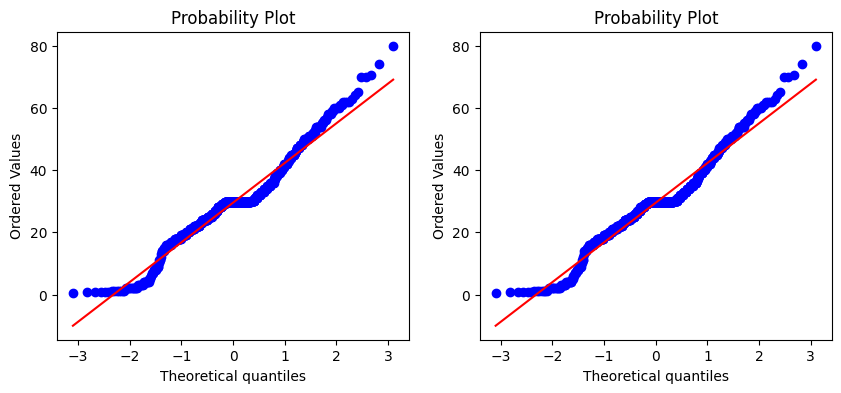

In [187]:
plt.figure(figsize=(10,4))
plt.subplot(121)
stats.probplot(x_train['Age'], dist="norm", plot=plt)
plt.subplot(122)
stats.probplot(x_train_transformed['Age'], dist="norm", plot=plt)
plt.show()

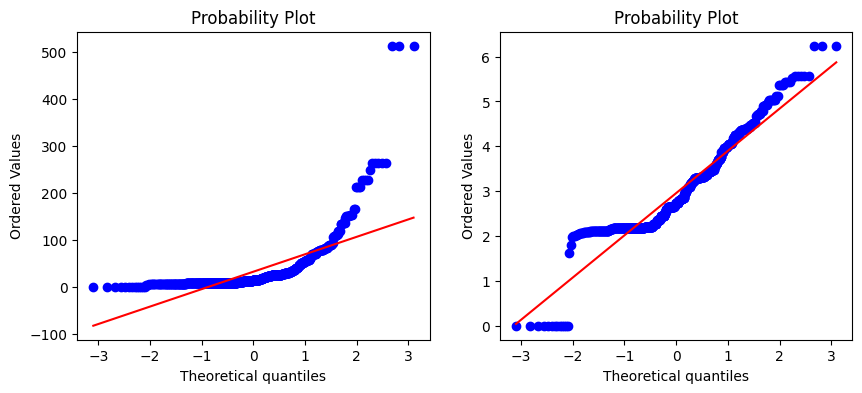

In [190]:
plt.figure(figsize=(10,4))

plt.subplot(121)
stats.probplot(x_train['Fare'], dist="norm", plot=plt)

plt.subplot(122)
stats.probplot(x_train_transformed['Fare_log'], dist="norm", plot=plt)

plt.show()
